# Localised PV Generation Forecasting — Copal Supermarket Energy Community (ECC)

**EnerTEF · TEF-EV (Leneda, Luxembourg) · Service 2 · D2.2 §2.5.2**

Probabilistic PV generation forecasts on the 15-minute Leneda grid for the Copal Supermarket
energy community (973.81 kWc, 6.48714 E / 49.70673 N): **intraday (up to 6 h)** and **day-ahead
(up to 24 h)**, as P10 / P50 / P90 quantiles, bounded by a fitted plant envelope and scored
against persistence.

This notebook is the complete, self-contained implementation. It loads the Leneda series in
`Data/`, builds leakage-safe features, selects the learning algorithm with a rule fixed before
the experiment, trains and evaluates the final models, and writes them — together with their
Hugging Face model card — to `Data/models/`. It needs only the packages in `requirements.txt`.

## How to run

```bash
python -m venv .venv
.venv\Scripts\activate            # macOS / Linux: source .venv/bin/activate
pip install -r requirements.txt
jupyter lab ECC_PV_Forecasting.ipynb     # or open it in VS Code
```

Run it top to bottom from the repository root. A full run takes about 30 minutes, almost all of
it the algorithm bake-off (§5), which fits 3 algorithms × 3 seeds × 2 horizon blocks × 3 quantiles.

| § | Section | Produces |
|---|---|---|
| 1 | Setup | paths, plant constants, method constants, library versions |
| 2 | Data | the 15-min PV series, quality flags, coverage, daily energy |
| 3 | Solar geometry and plant envelope | clear-sky reference, fitted kW-per-W/m² envelope and cap |
| 4 | Features and samples | the 22-feature vector per (issue time, target slot), leakage-safe |
| 5 | Algorithm bake-off | GBR vs LightGBM vs XGBoost over 3 seeds and the pre-registered rule's verdict |
| 6 | Final models and evaluation | hold-out accuracy per block and per horizon vs persistence |
| 7 | Example forecast | one 24 h P10/P50/P90 forecast package against the measured PV |
| 8 | Export | `Data/models/`: `.joblib` models, envelope, metrics, bake-off, model card |
| 9 | Publish to Hugging Face | opt-in upload of `Data/models/` |

## 1 · Setup

Everything the method depends on is declared here: the plant, the time grid, and the constants of
the forecasting method. The notebook resolves paths from the repository root.

In [1]:
import json
import os
import platform
import time
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

# joblib cannot count physical cores on recent Windows (no `wmic`) and prints a traceback when
# LightGBM asks for them; a core count below the logical total makes it skip that probe.
if os.name == "nt":
    os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) // 2)))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

ROOT = Path.cwd()
DATA_CSV = ROOT / "Data" / "ECC_master_PV_EMOB1_EMOB2_15min.csv"
MODEL_DIR = ROOT / "Data" / "models"
if not DATA_CSV.is_file():
    raise FileNotFoundError(f"{DATA_CSV} not found — start Jupyter from the repository root.")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Plant — Copal Supermarket energy community (ECC)
PLANT_ID = "copal-ecc"
CAPACITY_KWC = 973.81
LATITUDE, LONGITUDE = 49.70673, 6.48714
SLOT = pd.Timedelta(minutes=15)  # Leneda interval length

# Method constants
KCS_MAX = 1.3                    # clear-sky index cap (cloud enhancement can exceed 1)
NIGHT_GHI_WM2 = 10.0             # below this clear-sky GHI a slot counts as night
ENVELOPE_MIN_GHI_WM2 = 200.0     # well-lit slots used to fit the envelope slope
ENVELOPE_QUANTILE = 0.995        # envelope slope = this quantile of PV / clear-sky GHI
HOLDOUT_DAYS = 60                # trailing hold-out window
MAX_TRAIN_ROWS = 120_000         # most recent training rows kept per block
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}
MISSING = -1.0                   # missing-value code (with companion indicator features)
MODEL_VERSION = "1.0.0"
HF_REPO = "EnerTEF/Service2-PvForecast"
GITHUB_REPO = "https://github.com/ENERTEF/TEF-EV-Service-2----Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities-"

# Horizon blocks — one model per block because the information available differs by lead time.
BLOCKS = {
    "intraday": {"leads_h": (0.0, 6.0), "issue_hours_utc": [4, 6, 8, 10, 12, 14, 16, 18]},
    "day_ahead": {"leads_h": (6.0, 24.0), "issue_hours_utc": [0, 6, 12, 18]},
}

LIBS = {lib: version(lib) for lib in ("numpy", "pandas", "scikit-learn", "lightgbm", "xgboost", "joblib")}
print(f"data: {DATA_CSV.relative_to(ROOT).as_posix()}")
print(f"python {platform.python_version()} · " + " · ".join(f"{lib} {v}" for lib, v in LIBS.items()))

data: Data/ECC_master_PV_EMOB1_EMOB2_15min.csv
python 3.11.9 · numpy 1.26.4 · pandas 2.2.3 · scikit-learn 1.5.2 · lightgbm 4.5.0 · xgboost 2.1.3 · joblib 1.4.2


## 2 · Data — the 15-minute Leneda PV series

`Data/ECC_master_PV_EMOB1_EMOB2_15min.csv` is the Leneda master export of the Copal energy community
(same file as in the Service 1 repository). Timestamps (`Started at`) carry `+01:00` / `+02:00`
offsets and are converted to UTC. The target is `PV_TotalProduction_kW` (OBIS 1-1:2.29.0). Values
outside `[0, nameplate]` are clipped and flagged `edited`; empty cells are `missing` and are never
used as history or as a target.

,value
first usable interval (UTC),2023-10-11 22:00:00+00:00
last usable interval (UTC),2026-01-18 22:45:00+00:00
span (days),830.0
intervals in file,106944
usable intervals,79684
missing,27260
edited (clipped),0
max PV (kW),751.2


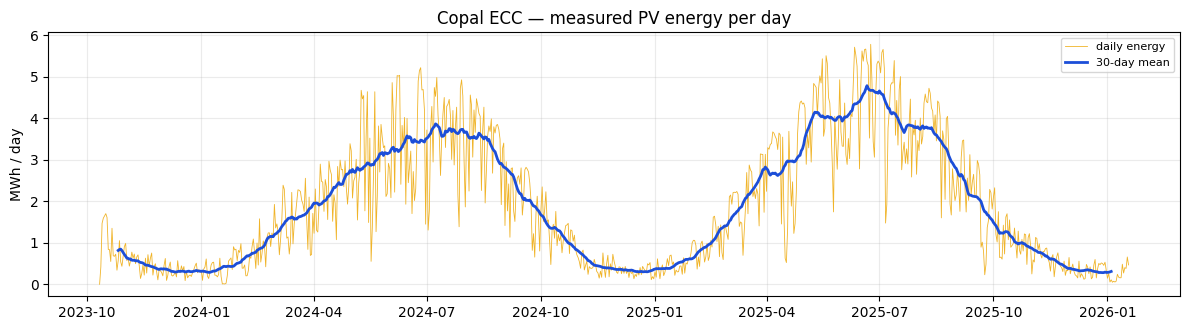

In [2]:
raw = pd.read_csv(DATA_CSV, usecols=["Started at", "PV_TotalProduction_kW"])
ts_utc = pd.to_datetime(raw["Started at"], utc=True, errors="coerce", format="ISO8601")
pv_raw = pd.to_numeric(raw["PV_TotalProduction_kW"], errors="coerce")
series = pd.DataFrame({"pv_raw": pv_raw.to_numpy()}, index=pd.DatetimeIndex(ts_utc, name="ts_utc"))
series = series[series.index.notna()].sort_index()
series["flag"] = np.select(
    [series.pv_raw.isna(), (series.pv_raw < 0) | (series.pv_raw > CAPACITY_KWC)],
    ["missing", "edited"],
    default="measured",
)
series["pv_kw"] = series.pv_raw.clip(0.0, CAPACITY_KWC)
usable = series.pv_kw.dropna()          # usable = measured or edited (clipped)
FIRST, LAST = usable.index[0], usable.index[-1]

coverage = pd.Series(
    {
        "first usable interval (UTC)": FIRST,
        "last usable interval (UTC)": LAST,
        "span (days)": round((LAST - FIRST) / pd.Timedelta(days=1), 1),
        "intervals in file": len(series),
        "usable intervals": len(usable),
        "missing": int((series.flag == "missing").sum()),
        "edited (clipped)": int((series.flag == "edited").sum()),
        "max PV (kW)": round(float(usable.max()), 1),
    }
)
display(coverage.to_frame("value"))

daily_mwh = usable.resample("D").sum() * 0.25 / 1000  # kW × 0.25 h per interval → MWh
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(daily_mwh.index, daily_mwh, lw=0.6, color="#f0b429", label="daily energy")
ax.plot(daily_mwh.index, daily_mwh.rolling(30, center=True).mean(), lw=2, color="#1c4ed8", label="30-day mean")
ax.set_ylabel("MWh / day")
ax.set_title("Copal ECC — measured PV energy per day")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3 · Solar geometry, clear-sky reference and the plant envelope

The model does not learn power directly. It learns the **clear-sky index** — measured PV divided by
the power the plant would produce under a clear sky — which removes the seasonal and diurnal solar
geometry from the target.

* **Solar position:** NOAA formulation (declination, equation of time, hour angle), evaluated at the
  midpoint of each 15-minute interval.
* **Clear-sky GHI:** Ineichen–Perez with the Kasten–Young air mass and Linke turbidity 3.0 (a
  representative Central-European value), sea level.
* **Envelope:** tilt and azimuth of the Copal plant are unknown, so the kW produced per W/m² of
  clear-sky GHI is fitted from history as the 99.5th percentile of `PV / clear-sky GHI` over well-lit
  slots (clear-sky GHI ≥ 200 W/m²), capped at nameplate scaling. The absolute cap is the 99.9th
  percentile of observed output. `clear-sky power = min(slope × clear-sky GHI, cap)`.

envelope: 0.798 kW per W/m² of clear-sky GHI, cap 662 kW (nameplate 973.81 kWc), fitted on 26,111 well-lit slots


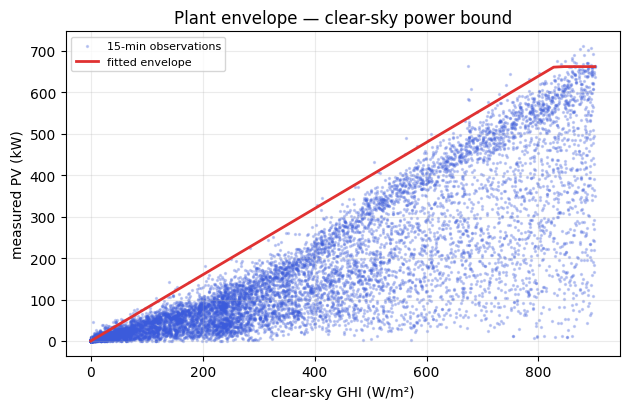

In [3]:
def solar_geometry(times: pd.DatetimeIndex) -> tuple[np.ndarray, np.ndarray]:
    # NOAA solar zenith (degrees) and extraterrestrial normal irradiance (W/m²) at UTC `times`.
    year_start = pd.to_datetime(times.year.astype(str) + "-01-01", utc=True)
    doy = np.asarray((times - year_start).total_seconds() / 86400.0)  # fractional, 0-based
    year_len = np.where(times.is_leap_year, 366.0, 365.0)
    g = 2.0 * np.pi / year_len * doy
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    minutes = np.asarray(times.hour * 60.0 + times.minute + times.second / 60.0)
    hour_angle = np.radians(((minutes + (eqtime + 4.0 * LONGITUDE)) % 1440.0) / 4.0 - 180.0)
    lat = np.radians(LATITUDE)
    cos_z = np.clip(np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(hour_angle), -1.0, 1.0)
    zenith = np.degrees(np.arccos(cos_z))
    dni_extra = 1361.0 * (1.0 + 0.033 * np.cos(2.0 * np.pi * doy / year_len))
    return zenith, dni_extra


def clear_sky_ghi(times: pd.DatetimeIndex, linke_turbidity: float = 3.0) -> tuple[np.ndarray, np.ndarray]:
    # Ineichen–Perez clear-sky GHI (W/m², sea level) and cos(zenith) at the midpoint of each interval.
    zenith, dni_extra = solar_geometry(times + SLOT / 2)
    cos_z = np.cos(np.radians(zenith))
    up = zenith < 90.0
    z = np.where(up, zenith, 0.0)
    airmass = 1.0 / (np.cos(np.radians(z)) + 0.50572 * (96.07995 - z) ** -1.6364)  # Kasten–Young
    ghi = 0.868 * dni_extra * np.maximum(cos_z, 1e-6) * np.exp(-0.0387 * airmass * linke_turbidity)
    return np.where(up, np.maximum(ghi, 0.0), 0.0), cos_z


# One row per 15-min slot, from the first observation to one day past the last (the longest lead).
grid = pd.DataFrame(index=pd.date_range(series.index[0], series.index[-1] + pd.Timedelta(days=1), freq=SLOT))
grid["cs_ghi"], grid["cos_z"] = clear_sky_ghi(grid.index)
grid["pv"] = usable.reindex(grid.index)

# Envelope fit (slope + cap) from usable history.
cs_at_obs = grid.cs_ghi.reindex(usable.index)
lit = cs_at_obs >= ENVELOPE_MIN_GHI_WM2
ENV_SLOPE = min(float(np.quantile((usable[lit] / cs_at_obs[lit]).to_numpy(), ENVELOPE_QUANTILE)), CAPACITY_KWC / 1000)
ENV_CAP_KW = min(float(np.quantile(usable.to_numpy(), 0.999)), CAPACITY_KWC)
envelope = {
    "kw_per_wm2": round(ENV_SLOPE, 6),
    "max_kw": round(ENV_CAP_KW, 3),
    "n_slots": int(lit.sum()),
    "quantile": ENVELOPE_QUANTILE,
    "method": "quantile of pv / clear-sky GHI over slots with clear-sky GHI >= 200 W/m² (Ineichen, TL=3)",
}

grid["cs_kw"] = (ENV_SLOPE * grid.cs_ghi).clip(0.0, ENV_CAP_KW)
daylight = (grid.cs_ghi >= NIGHT_GHI_WM2) & (grid.cs_kw > 0)
grid["kcs"] = (grid.pv / grid.cs_kw).clip(0.0, KCS_MAX).where(daylight & grid.pv.notna())

print(f"envelope: {ENV_SLOPE:.3f} kW per W/m² of clear-sky GHI, cap {ENV_CAP_KW:.0f} kW "
      f"(nameplate {CAPACITY_KWC} kWc), fitted on {int(lit.sum()):,} well-lit slots")

sample = pd.DataFrame({"cs": cs_at_obs, "pv": usable}).dropna().sample(20_000, random_state=0)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(sample.cs, sample.pv, s=2, alpha=0.25, color="#3b5bdb", label="15-min observations")
xs = np.linspace(0, sample.cs.max(), 50)
ax.plot(xs, np.minimum(ENV_SLOPE * xs, ENV_CAP_KW), color="#e03131", lw=2, label="fitted envelope")
ax.set_xlabel("clear-sky GHI (W/m²)")
ax.set_ylabel("measured PV (kW)")
ax.set_title("Plant envelope — clear-sky power bound")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4 · Features and samples — only what is known at issue time

A forecast is **issued** at a time `t₀` and predicts every 15-minute **target slot** of its horizon.
Intraday forecasts are issued every two hours through the daylight window (04–18 UTC) and cover leads
up to 6 h; day-ahead forecasts are issued every six hours (00, 06, 12, 18 UTC) and cover leads from 6 h
to 24 h — so across issue times the day-ahead model sees every time of day, including the next day's
daylight from an evening issue.

Each (issue time, target slot) pair gets the same 22-feature vector the internal service uses:

| Group | Features |
|---|---|
| Solar geometry at the target slot | `clear_sky_kw`, `clear_sky_ghi_wm2`, `cos_zenith`, time-of-day and day-of-year harmonics, `lead_time_hours` |
| NWP weather (reserved) | `has_weather`, GHI/DNI/DHI, cloud cover, temperature, wind, NWP clear-sky index — all `-1` here: this release trains **offline**, without weather inputs |
| Recent observations (issue time) | `has_recent`, `kcs_recent` (mean clear-sky index of the last 3 h for intraday, of the previous day for day-ahead), `pv_last_kw` / `kcs_last` (last observation ≤ 30 min before issue, intraday only) |
| 24 h lag | `pv_lag_24h_kw`, `kcs_lag_24h` — the same slot one day earlier |

**Leakage rule.** Every history lookup is restricted to observations *strictly before* the issue time,
so the training matrix contains nothing a live forecast could not have known. Missing values are
coded `-1` with companion indicators, so the trees branch on availability. Only daylight target
slots are used (night is 0 by construction).

In [4]:
FEATURE_NAMES = [
    "clear_sky_kw", "clear_sky_ghi_wm2", "cos_zenith", "tod_sin", "tod_cos", "doy_sin", "doy_cos",
    "lead_time_hours", "has_weather", "ghi_fc_wm2", "dni_fc_wm2", "dhi_fc_wm2", "cloud_fc_pct",
    "temp_fc_c", "wind_fc_ms", "kcs_fc", "has_recent", "kcs_recent", "pv_last_kw", "kcs_last",
    "pv_lag_24h_kw", "kcs_lag_24h",
]
WEATHER_FEATURES = ["ghi_fc_wm2", "dni_fc_wm2", "dhi_fc_wm2", "cloud_fc_pct", "temp_fc_c", "wind_fc_ms", "kcs_fc"]


def issue_times(block: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DatetimeIndex:
    # Issue schedule of `block` with start <= issue < end (issues without any prior history are dropped).
    days = pd.date_range(start.floor("D"), end, freq="D")
    issues = pd.DatetimeIndex(sorted(d + pd.Timedelta(hours=h) for d in days for h in BLOCKS[block]["issue_hours_utc"]))
    return issues[(issues >= start) & (issues < end) & (issues > FIRST)]


def issue_context(block: str, issues: pd.DatetimeIndex) -> pd.DataFrame:
    # Issue-time features: recent clear-sky index and the last observation (intraday only).
    ctx = pd.DataFrame(index=issues)
    if block == "intraday":
        ctx["kcs_recent"] = grid.kcs.rolling("3h", closed="left").mean().reindex(issues).to_numpy()
        prev1 = grid.pv.reindex(issues - SLOT).to_numpy()
        prev2 = grid.pv.reindex(issues - 2 * SLOT).to_numpy()
        kcs1 = grid.kcs.reindex(issues - SLOT).to_numpy()
        kcs2 = grid.kcs.reindex(issues - 2 * SLOT).to_numpy()
        # the last observation counts only if it is at most 30 min before the issue time
        ctx["pv_last_kw"] = np.where(~np.isnan(prev1), prev1, prev2)
        ctx["kcs_last"] = np.where(~np.isnan(prev1), kcs1, np.where(~np.isnan(prev2), kcs2, np.nan))
    else:
        daily_kcs = grid.kcs.groupby(grid.index.floor("D")).mean()
        ctx["kcs_recent"] = daily_kcs.reindex(issues.floor("D") - pd.Timedelta(days=1)).to_numpy()
        ctx["pv_last_kw"] = np.nan
        ctx["kcs_last"] = np.nan
    return ctx


def build_samples(block: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # Feature rows + clear-sky-index targets for every daylight target slot of every issue in [start, end).
    issues = issue_times(block, start, end)
    ctx = issue_context(block, issues)
    lo, hi = (int(h * 4) for h in BLOCKS[block]["leads_h"])
    leads = np.arange(lo, hi)
    issue_ns = np.repeat(issues.asi8, len(leads))
    k = np.tile(leads, len(issues))
    ts = pd.DatetimeIndex(pd.to_datetime(issue_ns + k * SLOT.value, utc=True))
    issue = pd.DatetimeIndex(pd.to_datetime(issue_ns, utc=True))

    at = grid.reindex(ts)
    keep = (at.pv.notna() & (at.cs_ghi >= NIGHT_GHI_WM2) & (at.cs_kw > 0)).to_numpy()
    ts, issue, k, at = ts[keep], issue[keep], k[keep], at[keep]

    lag_ts = ts - pd.Timedelta(hours=24)
    lag = grid.reindex(lag_ts)
    pv_lag = np.where(lag_ts < issue, lag.pv.to_numpy(), np.nan)
    kcs_lag = np.where(np.isnan(pv_lag), np.nan, lag.kcs.to_numpy())
    c = ctx.reindex(issue)

    minutes = ts.hour * 60 + ts.minute
    tod = 2 * np.pi * minutes / 1440.0
    doy = 2 * np.pi * (ts.dayofyear - 1) / 365.25
    f = pd.DataFrame(
        {
            "clear_sky_kw": at.cs_kw.to_numpy(),
            "clear_sky_ghi_wm2": at.cs_ghi.to_numpy(),
            "cos_zenith": np.maximum(at.cos_z.to_numpy(), 0.0),
            "tod_sin": np.sin(tod), "tod_cos": np.cos(tod),
            "doy_sin": np.sin(doy), "doy_cos": np.cos(doy),
            "lead_time_hours": k * 0.25,
            "has_weather": 0.0,
            **{name: MISSING for name in WEATHER_FEATURES},
            "has_recent": c.kcs_recent.notna().astype(float).to_numpy(),
            "kcs_recent": c.kcs_recent.fillna(MISSING).to_numpy(),
            "pv_last_kw": c.pv_last_kw.fillna(MISSING).to_numpy(),
            "kcs_last": c.kcs_last.fillna(MISSING).to_numpy(),
            "pv_lag_24h_kw": np.nan_to_num(pv_lag, nan=MISSING),
            "kcs_lag_24h": np.nan_to_num(kcs_lag, nan=MISSING),
        }
    )[FEATURE_NAMES]
    f["target_kcs"] = np.clip(at.pv.to_numpy() / at.cs_kw.to_numpy(), 0.0, KCS_MAX)
    f["actual_kw"] = at.pv.to_numpy()
    f["issue"] = issue
    f["ts"] = ts
    return f


SPLIT = LAST - pd.Timedelta(days=HOLDOUT_DAYS)
t0 = time.time()
samples = {
    block: {"train": build_samples(block, FIRST, SPLIT), "test": build_samples(block, SPLIT, LAST)}
    for block in BLOCKS
}
print(f"samples built in {time.time() - t0:.0f}s — train {FIRST:%d %b %Y} → {SPLIT:%d %b %Y}, "
      f"hold-out {SPLIT:%d %b %Y} → {LAST:%d %b %Y} ({HOLDOUT_DAYS} days)")
display(pd.DataFrame(
    {block: {"train rows": len(s["train"]), "hold-out rows": len(s["test"]),
             "issues (hold-out)": s["test"].issue.nunique()} for block, s in samples.items()}
).T)

samples built in 0s — train 11 Oct 2023 → 19 Nov 2025, hold-out 19 Nov 2025 → 18 Jan 2026 (60 days)


,train rows,hold-out rows,issues (hold-out)
intraday,95736,5265,360
day_ahead,104108,5253,238


## 5 · Algorithm bake-off — why this algorithm

Three gradient-boosting libraries compete as q10 / q50 / q90 quantile regressors of the clear-sky
index: **scikit-learn `GradientBoostingRegressor`** (the incumbent), **LightGBM** and **XGBoost**.
They see identical samples and hold-out, get the same capacity translated to each library's parameter
names (300 trees, depth 4, learning rate 0.05, minimum leaf size 40, row subsampling 0.85) with no
per-library tuning, and run over three seeds, so each gap can be compared with the noise from the
seed alone.

Predictions are scored exactly as the service post-processes them: quantiles clipped at 0 and
sorted, multiplied by the clear-sky power, and capped at the envelope. The metric is the daytime
MAE of the P50 in kW on the hold-out.

**The selection rule was fixed before the experiment was run:**

* primary metric — hold-out P50 MAE per block, averaged over the three seeds;
* one algorithm serves both blocks, so a challenger replaces GBR only if its MAE is **at least 3 %
  lower** averaged over the blocks, **and** that gap exceeds the average seed-to-seed MAE range,
  **and** it is **not worse on any block**, **and** its P10–P90 coverage is at most **5 points**
  below GBR's on every block;
* otherwise GBR stays. Training time is reported but is not a criterion.

In [5]:
SEEDS = (42, 43, 44)
INCUMBENT = "sklearn_gbr"
MIN_GAIN_PCT, MAX_COVERAGE_DROP_PTS = 3.0, 5.0
LABELS = {"sklearn_gbr": "scikit-learn GBR", "lightgbm": "LightGBM", "xgboost": "XGBoost"}

# (estimator class, name of its quantile-level argument, capacity-matched parameters)
ESTIMATORS = {
    "sklearn_gbr": (GradientBoostingRegressor, "alpha", {
        "loss": "quantile", "init": "zero", "n_estimators": 300, "max_depth": 4,
        "learning_rate": 0.05, "min_samples_leaf": 40, "subsample": 0.85}),
    "lightgbm": (LGBMRegressor, "alpha", {
        "objective": "quantile", "n_estimators": 300, "max_depth": 4, "num_leaves": 16,
        "learning_rate": 0.05, "min_child_samples": 40, "subsample": 0.85, "subsample_freq": 1, "verbose": -1}),
    "xgboost": (XGBRegressor, "quantile_alpha", {
        "objective": "reg:quantileerror", "tree_method": "hist", "n_estimators": 300, "max_depth": 4,
        "learning_rate": 0.05, "min_child_weight": 40, "subsample": 0.85}),
}


def to_kw(preds: dict[str, np.ndarray], cs_kw: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Serving post-processing: clip at 0, sort the quantiles, × clear-sky power, cap at the envelope.
    q = np.sort(np.maximum(np.vstack([preds[name] for name in QUANTILES]), 0.0), axis=0)
    return tuple(np.minimum(row * cs_kw, ENV_CAP_KW) for row in q)


def persistence_kw(test: pd.DataFrame) -> np.ndarray:
    # Same slot 24 h earlier; recent clear-sky index × clear-sky power when the lag is missing.
    cs = test.clear_sky_kw.to_numpy()
    lag, recent = test.pv_lag_24h_kw.to_numpy(), test.kcs_recent.to_numpy()
    kcs = np.where(recent != MISSING, recent, 0.5)
    p50 = np.where((lag != MISSING) & (test.lead_time_hours.to_numpy() <= 24.0),
                   np.where(cs > 0, np.minimum(lag, cs), 0.0), kcs * cs)
    return np.minimum(p50, ENV_CAP_KW)


def clear_sky_persistence_kw(test: pd.DataFrame) -> np.ndarray:
    # Physical baseline: recent (else lagged, else climatological 0.5) clear-sky index × clear-sky power.
    recent, lag = test.kcs_recent.to_numpy(), test.kcs_lag_24h.to_numpy()
    kcs = np.where(recent != MISSING, recent, np.where(lag != MISSING, lag, 0.5))
    return np.minimum(np.minimum(1.0, kcs) * test.clear_sky_kw.to_numpy(), ENV_CAP_KW)


def scores(actual: np.ndarray, p10: np.ndarray, p50: np.ndarray, p90: np.ndarray, pers: np.ndarray) -> dict:
    err = p50 - actual
    mae, mae_p = float(np.mean(np.abs(err))), float(np.mean(np.abs(pers - actual)))
    return {
        "n": len(actual),
        "mae_kw": round(mae, 3),
        "rmse_kw": round(float(np.sqrt(np.mean(err ** 2))), 3),
        "bias_kw": round(float(np.mean(err)), 3),
        "nmae_capacity_pct": round(100 * mae / CAPACITY_KWC, 3),
        "r2": round(1 - float(np.sum(err ** 2)) / float(np.sum((actual - actual.mean()) ** 2)), 3),
        "coverage_p10_p90_pct": round(100 * float(np.mean((p10 <= actual) & (actual <= p90))), 1),
        "persistence_mae_kw": round(mae_p, 3),
        "skill_vs_persistence_pct": round(100 * (1 - mae / mae_p), 2),
    }


def fit_quantiles(name: str, X: np.ndarray, y: np.ndarray, seed: int) -> tuple[dict, float]:
    cls, alpha_arg, params = ESTIMATORS[name]
    models, fit_s = {}, 0.0
    for q, alpha in QUANTILES.items():
        est = cls(**params, **{alpha_arg: alpha}, random_state=seed)
        t0 = time.perf_counter()
        est.fit(X, y)
        fit_s += time.perf_counter() - t0
        models[q] = est
    return models, fit_s


results, fitted_42 = {}, {}
t_all = time.time()
for block, s in samples.items():
    train = s["train"].iloc[-MAX_TRAIN_ROWS:]
    X, y = train[FEATURE_NAMES].to_numpy(), train.target_kcs.to_numpy()
    test = s["test"]
    X_te, cs_te, actual = test[FEATURE_NAMES].to_numpy(), test.clear_sky_kw.to_numpy(), test.actual_kw.to_numpy()
    pers = persistence_kw(test)
    results[block] = {}
    for name in ESTIMATORS:
        runs = []
        for seed in SEEDS:
            models, fit_s = fit_quantiles(name, X, y, seed)
            p10, p50, p90 = to_kw({q: m.predict(X_te) for q, m in models.items()}, cs_te)
            runs.append({"seed": seed, "fit_s": round(fit_s, 1), **scores(actual, p10, p50, p90, pers)})
            if seed == 42:
                fitted_42[(block, name)] = models
        mae = [r["mae_kw"] for r in runs]
        results[block][name] = {
            "mae_kw": round(float(np.mean(mae)), 3), "mae_min_kw": min(mae), "mae_max_kw": max(mae),
            "coverage_pct": round(float(np.mean([r["coverage_p10_p90_pct"] for r in runs])), 1),
            "fit_s": round(float(np.mean([r["fit_s"] for r in runs])), 1), "runs": runs,
        }
        print(f"{block:9s} {LABELS[name]:17s} MAE {results[block][name]['mae_kw']:.2f} kW "
              f"[{min(mae):.2f}–{max(mae):.2f}]  fit {results[block][name]['fit_s']:.0f} s/seed")
print(f"bake-off finished in {(time.time() - t_all) / 60:.1f} min")

intraday  scikit-learn GBR  MAE 18.22 kW [18.19–18.27]  fit 252 s/seed


intraday  LightGBM          MAE 17.75 kW [17.66–17.88]  fit 2 s/seed


intraday  XGBoost           MAE 17.87 kW [17.86–17.87]  fit 17 s/seed


day_ahead scikit-learn GBR  MAE 23.31 kW [23.23–23.39]  fit 244 s/seed


day_ahead LightGBM          MAE 22.75 kW [22.42–23.04]  fit 2 s/seed


day_ahead XGBoost           MAE 22.82 kW [22.44–23.17]  fit 19 s/seed
bake-off finished in 26.8 min


| Algorithm | intraday P50 MAE (kW) | day_ahead P50 MAE (kW) | P10–P90 coverage (intraday / day_ahead) | Fit time (all blocks, per seed) | Verdict |
|---|---|---|---|---|---|
| scikit-learn GBR | 18.2 [18.2–18.3] | 23.3 [23.2–23.4] | 72.4 / 66.4 % | 496 s | incumbent — **selected** |
| LightGBM | 17.7 [17.7–17.9] | 22.7 [22.4–23.0] | 71.1 / 69.4 % | 5 s | rejected — mean MAE gain +2.5 % is below the 3 % bar |
| XGBoost | 17.9 [17.9–17.9] | 22.8 [22.4–23.2] | 71.5 / 69.5 % | 36 s | rejected — mean MAE gain +2.0 % is below the 3 % bar |

MAE is the mean [min–max] over seeds 42, 43, 44.

**scikit-learn GBR is retained** — no challenger cleared the rule.

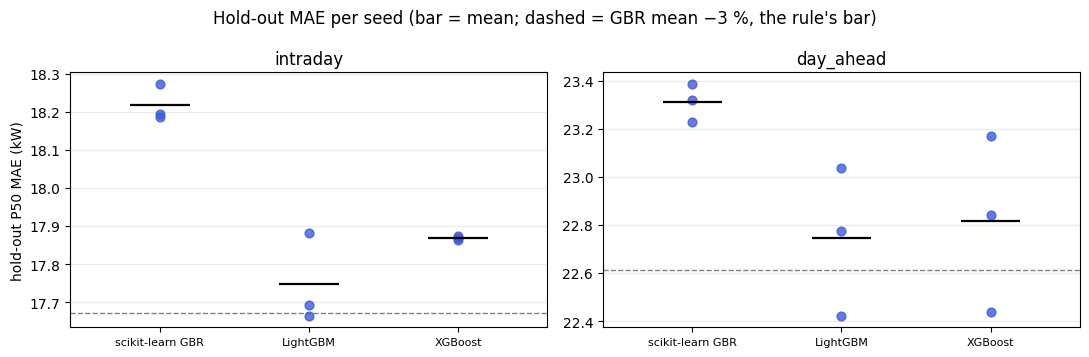

In [6]:
def select(results: dict) -> tuple[str, dict]:
    # Apply the pre-registered rule; return the selected algorithm and a verdict per challenger.
    verdicts = {}
    for name in ESTIMATORS:
        if name == INCUMBENT:
            continue
        gains, noises, failures = {}, [], []
        for block, res in results.items():
            inc, ch = res[INCUMBENT], res[name]
            gain = 100 * (inc["mae_kw"] - ch["mae_kw"]) / inc["mae_kw"]
            spread = max(inc["mae_max_kw"] - inc["mae_min_kw"], ch["mae_max_kw"] - ch["mae_min_kw"])
            noises.append(100 * spread / inc["mae_kw"])
            drop = inc["coverage_pct"] - ch["coverage_pct"]
            gains[block] = round(gain, 1)
            if gain < 0:
                failures.append(f"worse on {block} ({gain:+.1f} %)")
            if drop > MAX_COVERAGE_DROP_PTS:
                failures.append(f"coverage drops {drop:.1f} pts on {block}")
        mean_gain, noise = float(np.mean(list(gains.values()))), float(np.mean(noises))
        if mean_gain < MIN_GAIN_PCT:
            failures.insert(0, f"mean MAE gain {mean_gain:+.1f} % is below the {MIN_GAIN_PCT:g} % bar")
        if mean_gain <= noise:
            failures.append(f"gap is within the {noise:.1f} % seed-to-seed range")
        verdicts[name] = {
            "mae_gain_pct": gains, "mean_mae_gain_pct": round(mean_gain, 1), "seed_range_pct": round(noise, 1),
            "passes": not failures,
            "reason": "; ".join(failures) if failures else
            f"MAE {mean_gain:.1f} % lower on average (> {MIN_GAIN_PCT:g} % and > {noise:.1f} % seed range), "
            "not worse on any block, coverage kept",
        }
    passing = [n for n, v in verdicts.items() if v["passes"]]
    return (max(passing, key=lambda n: verdicts[n]["mean_mae_gain_pct"]) if passing else INCUMBENT), verdicts


SELECTED, verdicts = select(results)


def selection_markdown() -> str:
    blocks = list(results)
    lines = [
        "| Algorithm | " + " | ".join(f"{b} P50 MAE (kW)" for b in blocks)
        + f" | P10–P90 coverage ({' / '.join(blocks)}) | Fit time (all blocks, per seed) | Verdict |",
        "|---|" + "---|" * (len(blocks) + 3),
    ]
    for name in ESTIMATORS:
        cells = [f"{results[b][name]['mae_kw']:.1f} [{results[b][name]['mae_min_kw']:.1f}–{results[b][name]['mae_max_kw']:.1f}]"
                 for b in blocks]
        cov = " / ".join(f"{results[b][name]['coverage_pct']:.1f}" for b in blocks)
        fit = sum(results[b][name]["fit_s"] for b in blocks)
        if name == INCUMBENT:
            verdict = "incumbent — **selected**" if SELECTED == INCUMBENT else "incumbent — replaced"
        else:
            verdict = ("**selected** — " if SELECTED == name else "rejected — ") + verdicts[name]["reason"]
        lines.append(f"| {LABELS[name]} | {' | '.join(cells)} | {cov} % | {fit:.0f} s | {verdict} |")
    decision = (f"**{LABELS[INCUMBENT]} is retained** — no challenger cleared the rule."
                if SELECTED == INCUMBENT else f"**{LABELS[SELECTED]} replaces {LABELS[INCUMBENT]}** — it cleared every condition.")
    return "\n".join(lines) + f"\n\nMAE is the mean [min–max] over seeds {', '.join(map(str, SEEDS))}.\n\n{decision}"


display(Markdown(selection_markdown()))

fig, axes = plt.subplots(1, len(results), figsize=(11, 3.6))
for ax, (block, res) in zip(np.atleast_1d(axes), results.items()):
    bar = res[INCUMBENT]["mae_kw"] * (1 - MIN_GAIN_PCT / 100)
    for i, name in enumerate(ESTIMATORS):
        maes = [r["mae_kw"] for r in res[name]["runs"]]
        ax.scatter([i] * len(maes), maes, s=40, color="#3b5bdb", alpha=0.8, zorder=3)
        ax.hlines(res[name]["mae_kw"], i - 0.2, i + 0.2, color="black", lw=1.6, zorder=4)
    ax.axhline(bar, ls="--", lw=1, color="grey")
    ax.set_xticks(range(len(ESTIMATORS)), [LABELS[n] for n in ESTIMATORS], fontsize=8)
    ax.set_xlim(-0.6, len(ESTIMATORS) - 0.4)
    ax.set_title(block)
    ax.grid(alpha=0.25, axis="y")
np.atleast_1d(axes)[0].set_ylabel("hold-out P50 MAE (kW)")
fig.suptitle(f"Hold-out MAE per seed (bar = mean; dashed = GBR mean −{MIN_GAIN_PCT:g} %, the rule's bar)")
fig.tight_layout()
plt.show()

## 6 · Final models and hold-out evaluation

The served models are the selected algorithm's seed-42 fits from the bake-off (the same fit, not a
retrain). They are evaluated on the 60-day hold-out against **persistence** (same slot 24 h earlier)
and **clear-sky persistence** (recent clear-sky index × clear-sky power), per block and — as the
service specification asks — per forecast horizon: < 1 h, 1–6 h and day-ahead (6–24 h).
Everything is out-of-sample: the hold-out never touched training.

,slots,MAE (kW),RMSE (kW),bias (kW),nMAE (% of kWc),R²,P10–P90 coverage (%),persistence MAE (kW),skill vs persistence (%),clear-sky persistence MAE (kW)
intraday,5265,18.194,24.730,-0.245,1.868,0.514,71.7,24.608,26.06,20.838
day_ahead,5253,23.229,29.981,-2.636,2.385,0.286,67.3,24.395,4.78,24.646


,n,mae_kw,nmae_capacity_pct,rmse_kw,r2,coverage_p10_p90_pct,persistence_mae_kw,skill_vs_persistence_pct
< 1 h,960,12.085,1.241,17.633,0.752,75.2,23.708,49.03
1–6 h,4305,19.557,2.008,26.050,0.460,70.9,24.809,21.17
day-ahead (6–24 h),5253,23.229,2.385,29.981,0.286,67.3,24.395,4.78


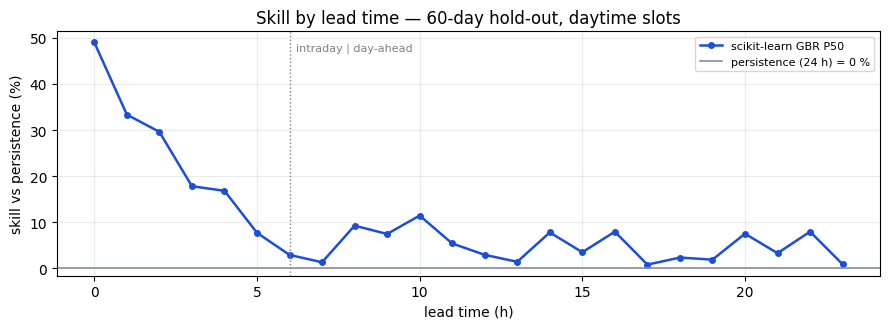

In [7]:
final = {block: fitted_42[(block, SELECTED)] for block in BLOCKS}
evaluation, per_lead = {}, []
for block, s in samples.items():
    test = s["test"]
    X_te = test[FEATURE_NAMES].to_numpy()
    p10, p50, p90 = to_kw({q: m.predict(X_te) for q, m in final[block].items()}, test.clear_sky_kw.to_numpy())
    pers, cs_pers = persistence_kw(test), clear_sky_persistence_kw(test)
    actual = test.actual_kw.to_numpy()
    evaluation[block] = scores(actual, p10, p50, p90, pers)
    evaluation[block]["clear_sky_persistence_mae_kw"] = round(float(np.mean(np.abs(cs_pers - actual))), 3)
    per_lead.append(pd.DataFrame({"lead_h": test.lead_time_hours.to_numpy(), "actual": actual,
                                  "p10": p10, "p50": p50, "p90": p90, "pers": pers}))

display(pd.DataFrame(evaluation).T.astype({"n": int}).rename(columns={
    "n": "slots", "mae_kw": "MAE (kW)", "rmse_kw": "RMSE (kW)", "bias_kw": "bias (kW)",
    "nmae_capacity_pct": "nMAE (% of kWc)", "r2": "R²", "coverage_p10_p90_pct": "P10–P90 coverage (%)",
    "persistence_mae_kw": "persistence MAE (kW)", "skill_vs_persistence_pct": "skill vs persistence (%)",
    "clear_sky_persistence_mae_kw": "clear-sky persistence MAE (kW)"}))

leads = pd.concat(per_lead, ignore_index=True)
# Buckets follow the blocks: intraday leads are 0–5.75 h, day-ahead leads 6–23.75 h.
buckets = pd.cut(leads.lead_h, [0.0, 1.0, 6.0, 24.0], right=False, labels=["< 1 h", "1–6 h", "day-ahead (6–24 h)"])
horizon_scores = {
    str(label): scores(g.actual.to_numpy(), g.p10.to_numpy(), g.p50.to_numpy(), g.p90.to_numpy(), g.pers.to_numpy())
    for label, g in leads.groupby(buckets, observed=True)
}
display(pd.DataFrame(horizon_scores).T.astype({"n": int})[["n", "mae_kw", "nmae_capacity_pct", "rmse_kw", "r2",
                                        "coverage_p10_p90_pct", "persistence_mae_kw", "skill_vs_persistence_pct"]])

# Skill by lead hour: each lead hour mixes different times of day (issues every 2 h / 6 h), so raw MAE
# mostly tracks how much sun those slots get; skill compares model and persistence on the same slots.
by_hour = (
    leads.assign(hour=np.floor(leads.lead_h), model=(leads.p50 - leads.actual).abs(),
                 persistence=(leads.pers - leads.actual).abs())
    .groupby("hour")[["model", "persistence"]].mean()
)
skill = 100 * (1 - by_hour.model / by_hour.persistence)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(skill.index, skill, marker="o", ms=4, lw=1.8, color="#1c4ed8", label=f"{LABELS[SELECTED]} P50")
ax.axhline(0, color="#868e96", lw=1.2, label="persistence (24 h) = 0 %")
ax.axvline(6, ls=":", color="grey", lw=1)
ax.text(6.2, skill.max(), "intraday | day-ahead", va="top", fontsize=8, color="grey")
ax.set_xlabel("lead time (h)")
ax.set_ylabel("skill vs persistence (%)")
ax.set_title("Skill by lead time — 60-day hold-out, daytime slots")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7 · Example forecast package

Forecasts as a consumer receives them: three 24-hour packages issued at 18:00 UTC on consecutive
hold-out evenings, each forecasting the **next day**. The first 6 hours (intraday model) fall at night,
so the whole next-day daylight profile comes from the day-ahead model. P10–P90 is the uncertainty band
and night slots are zero by construction. Single days swing both ways against persistence — the
hold-out statistics in §6 are the numbers to quote.

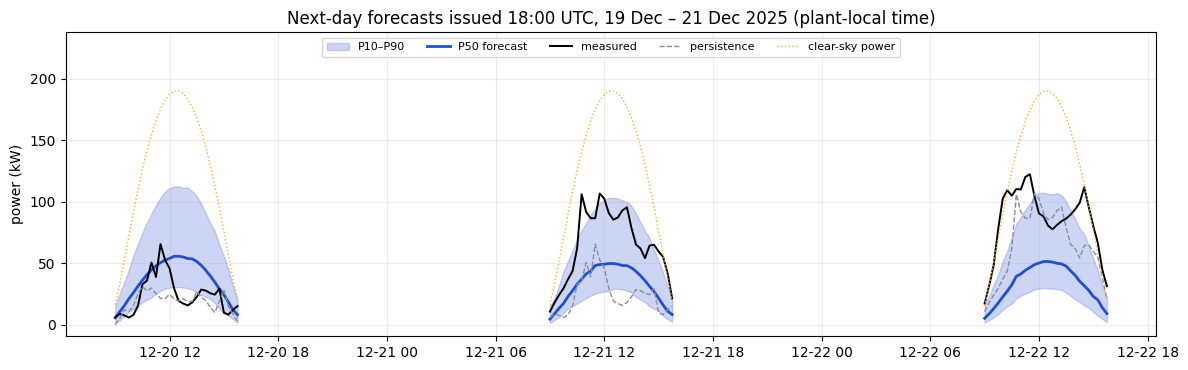

,daylight slots,P50 MAE (kW),persistence MAE (kW)
issued (UTC),,,
2025-12-19 18:00:00+00:00,28,14.3,10.3
2025-12-20 18:00:00+00:00,28,32.2,40.9
2025-12-21 18:00:00+00:00,28,50.6,23.2


In [8]:
evening_issues = [pd.Timestamp(i) for i in samples["day_ahead"]["test"].issue.unique() if pd.Timestamp(i).hour == 18]
mid = len(evening_issues) // 2
ISSUES = evening_issues[mid:mid + 3]  # three consecutive mid-hold-out evenings
parts = []
for issue in ISSUES:
    for block in BLOCKS:
        t = samples[block]["test"]
        t = t[t.issue == issue]
        if t.empty:
            continue
        p10, p50, p90 = to_kw({q: m.predict(t[FEATURE_NAMES].to_numpy()) for q, m in final[block].items()},
                              t.clear_sky_kw.to_numpy())
        parts.append(pd.DataFrame({"ts": t.ts, "issue": issue, "p10": p10, "p50": p50, "p90": p90,
                                   "actual": t.actual_kw.to_numpy(), "clear_sky": t.clear_sky_kw.to_numpy(),
                                   "persistence": persistence_kw(t)}))
pkg = pd.concat(parts).set_index("ts").sort_index()
pkg.index = pd.DatetimeIndex(pkg.index).tz_convert("Europe/Luxembourg")

fig, ax = plt.subplots(figsize=(12, 3.8))
for n, (issue, day) in enumerate(pkg.groupby("issue")):  # one daylight segment per package — no lines across nights
    first = n == 0
    ax.fill_between(day.index, day.p10, day.p90, alpha=0.25, color="#3b5bdb", label="P10–P90" if first else None)
    ax.plot(day.index, day.p50, lw=2, color="#1c4ed8", label="P50 forecast" if first else None)
    ax.plot(day.index, day.actual, lw=1.4, color="black", label="measured" if first else None)
    ax.plot(day.index, day.persistence, lw=1, ls="--", color="#868e96", label="persistence" if first else None)
    ax.plot(day.index, day.clear_sky, lw=1, ls=":", color="#f0b429", label="clear-sky power" if first else None)
ax.set_title(f"Next-day forecasts issued 18:00 UTC, {ISSUES[0]:%d %b} – {ISSUES[-1]:%d %b %Y} (plant-local time)")
ax.set_ylabel("power (kW)")
ax.set_ylim(top=pkg[["p90", "actual", "clear_sky"]].to_numpy().max() * 1.25)  # headroom for the legend
ax.legend(fontsize=8, ncol=5, loc="upper center")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

errors = pkg.assign(model=(pkg.p50 - pkg.actual).abs(), pers=(pkg.persistence - pkg.actual).abs())
display(errors.groupby("issue").agg(**{
    "daylight slots": ("model", "size"), "P50 MAE (kW)": ("model", "mean"), "persistence MAE (kW)": ("pers", "mean"),
}).round(1).rename_axis("issued (UTC)"))

## 8 · Export — `Data/models/`

`Data/models/` holds everything needed to reuse the models, and is exactly the content of the
Hugging Face repository [`EnerTEF/Service2-PvForecast`](https://huggingface.co/EnerTEF/Service2-PvForecast):

| File | Content |
|---|---|
| `pv_quantile_intraday.joblib`, `pv_quantile_day_ahead.joblib` | the fitted q10 / q50 / q90 estimators per block, with the feature order |
| `envelope.json` | the fitted plant envelope — required to convert the clear-sky index to kW |
| `metrics.json` | hold-out metrics per block and horizon, windows, parameters, library versions |
| `benchmark.json` | the full bake-off: per-seed results, the rule and the verdicts |
| `README.md` | the Hugging Face model card |

In [9]:
trained_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
windows = {"train": [FIRST.isoformat(), SPLIT.isoformat()], "holdout": [SPLIT.isoformat(), LAST.isoformat()]}
_, _, selected_params = ESTIMATORS[SELECTED]

for block in BLOCKS:
    joblib.dump(
        {
            "model": f"pv_quantile_{block}", "version": MODEL_VERSION, "block": block,
            "leads_h": BLOCKS[block]["leads_h"], "target": "clear-sky index (kcs)", "algorithm": SELECTED,
            "features": FEATURE_NAMES, "quantiles": final[block], "trained_at": trained_at,
        },
        MODEL_DIR / f"pv_quantile_{block}.joblib",
    )

(MODEL_DIR / "envelope.json").write_text(json.dumps({**envelope, "fitted_at": trained_at}, indent=2), encoding="utf-8")
metrics = {
    "model_version": MODEL_VERSION, "trained_at": trained_at, "plant_id": PLANT_ID, "capacity_kwc": CAPACITY_KWC,
    "algorithm": SELECTED, "params": {**selected_params, "random_state": 42}, "quantiles": QUANTILES,
    "weather_source": "none", "windows": windows, "blocks": BLOCKS, "envelope": envelope,
    "n_train": {b: int(min(len(s["train"]), MAX_TRAIN_ROWS)) for b, s in samples.items()},
    "holdout_by_block": evaluation, "holdout_by_horizon": horizon_scores,
    "environment": {"python": platform.python_version(), **LIBS},
}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str), encoding="utf-8")
benchmark = {
    "created_at": trained_at, "seeds": list(SEEDS), "incumbent": INCUMBENT, "selected": SELECTED,
    "rule": {"min_mean_gain_pct": MIN_GAIN_PCT, "max_coverage_drop_pts": MAX_COVERAGE_DROP_PTS,
             "not_worse_on_any_block": True, "gain_must_exceed_seed_range": True},
    "params": {name: params for name, (_, _, params) in ESTIMATORS.items()},
    "results": results, "verdicts": verdicts, "windows": windows,
    "environment": {"python": platform.python_version(), **LIBS},
}
(MODEL_DIR / "benchmark.json").write_text(json.dumps(benchmark, indent=2, default=str), encoding="utf-8")
print("wrote:", ", ".join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())))

wrote: README.md, benchmark.json, envelope.json, metrics.json, pv_quantile_day_ahead.joblib, pv_quantile_intraday.joblib


In [10]:
LIBRARY_TAG = {"sklearn_gbr": "scikit-learn", "lightgbm": "lightgbm", "xgboost": "xgboost"}[SELECTED]


def md_table(rows: dict, columns: dict) -> str:
    head = "| | " + " | ".join(columns.values()) + " |\n|---|" + "---|" * len(columns)
    body = "\n".join(f"| {name} | " + " | ".join(f"{v[c]:.2f}" for c in columns) + " |" for name, v in rows.items())
    return head + "\n" + body


card = f'''---
library_name: {LIBRARY_TAG}
license: mit
pipeline_tag: tabular-regression
tags:
- energy
- solar
- pv-forecasting
- probabilistic-forecasting
- quantile-regression
- gradient-boosting
- energy-community
- enertef
---

# Service 2 — localised PV generation forecasting (Copal ECC)

Probabilistic **PV generation** models for the EnerTEF TEF-EV localised PV forecasting service
(D2.2 §2.5.2), trained on the Copal Supermarket energy community in Luxembourg (973.81 kWc,
Leneda 15-minute metering). They predict the **clear-sky index** (PV ÷ clear-sky power) at the
q10 / q50 / q90 quantiles; multiplied by the clear-sky power of the fitted plant envelope, they give
P10 / P50 / P90 generation in kW for every 15-minute slot of the next **24 hours**.

Code, data and the full experiment: [{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO}) (notebook `ECC_PV_Forecasting.ipynb`).

| Block | Lead time | Issued | Model file |
|---|---|---|---|
| intraday | 0–6 h | every 2 h, 04–18 UTC | `pv_quantile_intraday.joblib` |
| day-ahead | 6–24 h | every 6 h, 00/06/12/18 UTC | `pv_quantile_day_ahead.joblib` |

## Model

| Field | Value |
|---|---|
| Algorithm | {LABELS[SELECTED]} — 3 quantile regressors (q10 / q50 / q90) per block, chosen by the bake-off below |
| Parameters | `{json.dumps({**selected_params, "random_state": 42})}` |
| Target | clear-sky index, clipped to [0, {KCS_MAX}] |
| Features | 22 (solar geometry, lead time, recent and 24 h-lagged observations; NWP columns reserved, `-1` in this offline release) |
| Weather inputs | none (offline) |
| Training window | {FIRST:%d %b %Y} → {SPLIT:%d %b %Y} |
| Hold-out | {SPLIT:%d %b %Y} → {LAST:%d %b %Y} ({HOLDOUT_DAYS} days, winter) |
| Version | {MODEL_VERSION} ({trained_at[:10]}) |

## Hold-out accuracy (daytime 15-minute slots, out-of-sample)

{md_table(evaluation, {"mae_kw": "MAE (kW)", "rmse_kw": "RMSE (kW)", "r2": "R²", "coverage_p10_p90_pct": "P10–P90 coverage (%)", "persistence_mae_kw": "persistence MAE (kW)", "skill_vs_persistence_pct": "skill vs persistence (%)"})}

By forecast horizon:

{md_table(horizon_scores, {"mae_kw": "MAE (kW)", "nmae_capacity_pct": "nMAE (% of kWc)", "r2": "R²", "coverage_p10_p90_pct": "P10–P90 coverage (%)", "skill_vs_persistence_pct": "skill vs persistence (%)"})}

Without weather inputs the day-ahead model learns the climatology of the clear-sky index, so it sits
close to persistence; the intraday model earns its skill from recent observations. NWP features
(e.g. Open-Meteo, MeteoLux) are what lifts day-ahead skill.

## Model selection — why {LABELS[SELECTED]}

scikit-learn GBR (the incumbent), LightGBM and XGBoost were trained on identical samples and hold-out,
with the same capacity translated to each library and no per-library tuning, over three seeds. The rule
was fixed before the run: a challenger replaces GBR only if its P50 MAE is at least {MIN_GAIN_PCT:g} % lower
averaged over the blocks, the gap exceeds the seed-to-seed range, it is not worse on any block, and its
P10–P90 coverage drops by at most {MAX_COVERAGE_DROP_PTS:g} points on every block.

{selection_markdown()}

Per-seed results: `benchmark.json`.

## Files

| File | Content |
|---|---|
| `pv_quantile_<block>.joblib` | dict with `features` (order), `quantiles` (`q10`/`q50`/`q90` estimators) and metadata |
| `envelope.json` | fitted plant envelope: `kw_per_wm2` (clear-sky power slope) and `max_kw` (cap) |
| `metrics.json` | hold-out metrics per block and horizon, windows, parameters, library versions |
| `benchmark.json` | algorithm bake-off: per-seed results, rule, verdicts |

## Usage

```python
import json
import joblib
import numpy as np

bundle = joblib.load("pv_quantile_intraday.joblib")
envelope = json.load(open("envelope.json"))
# X: rows of the 22 features in bundle["features"] order — built exactly as in the notebook (§4)
kcs = np.sort([np.maximum(est.predict(X), 0) for est in bundle["quantiles"].values()], axis=0)
clear_sky_kw = np.minimum(envelope["kw_per_wm2"] * clear_sky_ghi_wm2, envelope["max_kw"])
p10_kw, p50_kw, p90_kw = np.minimum(kcs * clear_sky_kw, envelope["max_kw"])
```

The feature builder (solar geometry, clear-sky model, leakage-safe history lookups) is part of the
notebook in the GitHub repository; use it unchanged so the inputs match training.

## Data

Leneda 15-minute smart-meter production of the Copal Supermarket energy community PV plant
(OBIS 1-1:2.29.0), {FIRST:%d %b %Y} → {LAST:%d %b %Y}, as published with the EnerTEF TEF-EV service
repositories (`Data/ECC_master_PV_EMOB1_EMOB2_15min.csv`).

## Limitations

- Single plant, empirical envelope (tilt and azimuth unknown): a site-specific model, not a general PV model.
- Offline release without weather inputs — day-ahead skill over persistence is small.
- P10 / P90 are raw quantile outputs (no conformal recalibration); coverage is reported above.
- Horizon ends at 24 h by design (intraday + day-ahead).

## Attribution

EnerTEF — TEF-EV experimentation facility (Leneda, Luxembourg), Service 2. MIT licence.
'''
(MODEL_DIR / "README.md").write_text(card, encoding="utf-8")
display(Markdown(card.split("## Model selection")[0].split("---", 2)[2]))



# Service 2 — localised PV generation forecasting (Copal ECC)

Probabilistic **PV generation** models for the EnerTEF TEF-EV localised PV forecasting service
(D2.2 §2.5.2), trained on the Copal Supermarket energy community in Luxembourg (973.81 kWc,
Leneda 15-minute metering). They predict the **clear-sky index** (PV ÷ clear-sky power) at the
q10 / q50 / q90 quantiles; multiplied by the clear-sky power of the fitted plant envelope, they give
P10 / P50 / P90 generation in kW for every 15-minute slot of the next **24 hours**.

Code, data and the full experiment: [TEF-EV-Service-2----Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities-](https://github.com/ENERTEF/TEF-EV-Service-2----Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities-) (notebook `ECC_PV_Forecasting.ipynb`).

| Block | Lead time | Issued | Model file |
|---|---|---|---|
| intraday | 0–6 h | every 2 h, 04–18 UTC | `pv_quantile_intraday.joblib` |
| day-ahead | 6–24 h | every 6 h, 00/06/12/18 UTC | `pv_quantile_day_ahead.joblib` |

## Model

| Field | Value |
|---|---|
| Algorithm | scikit-learn GBR — 3 quantile regressors (q10 / q50 / q90) per block, chosen by the bake-off below |
| Parameters | `{"loss": "quantile", "init": "zero", "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05, "min_samples_leaf": 40, "subsample": 0.85, "random_state": 42}` |
| Target | clear-sky index, clipped to [0, 1.3] |
| Features | 22 (solar geometry, lead time, recent and 24 h-lagged observations; NWP columns reserved, `-1` in this offline release) |
| Weather inputs | none (offline) |
| Training window | 11 Oct 2023 → 19 Nov 2025 |
| Hold-out | 19 Nov 2025 → 18 Jan 2026 (60 days, winter) |
| Version | 1.0.0 (2026-09-30) |

## Hold-out accuracy (daytime 15-minute slots, out-of-sample)

| | MAE (kW) | RMSE (kW) | R² | P10–P90 coverage (%) | persistence MAE (kW) | skill vs persistence (%) |
|---|---|---|---|---|---|---|
| intraday | 18.19 | 24.73 | 0.51 | 71.70 | 24.61 | 26.06 |
| day_ahead | 23.23 | 29.98 | 0.29 | 67.30 | 24.39 | 4.78 |

By forecast horizon:

| | MAE (kW) | nMAE (% of kWc) | R² | P10–P90 coverage (%) | skill vs persistence (%) |
|---|---|---|---|---|---|
| < 1 h | 12.09 | 1.24 | 0.75 | 75.20 | 49.03 |
| 1–6 h | 19.56 | 2.01 | 0.46 | 70.90 | 21.17 |
| day-ahead (6–24 h) | 23.23 | 2.38 | 0.29 | 67.30 | 4.78 |

Without weather inputs the day-ahead model learns the climatology of the clear-sky index, so it sits
close to persistence; the intraday model earns its skill from recent observations. NWP features
(e.g. Open-Meteo, MeteoLux) are what lifts day-ahead skill.



## 9 · Publish to Hugging Face (opt-in)

Uploads `Data/models/` to `EnerTEF/Service2-PvForecast`. Remote `.json` / `.joblib` files that are not
in the folder are removed, so artifacts of a retired model never linger on the hub. Requires a
write-scoped token: run `hf auth login` once (or set `HF_TOKEN`), then set `UPLOAD_TO_HF = True`.

In [11]:
UPLOAD_TO_HF = False

if UPLOAD_TO_HF:
    from huggingface_hub import HfApi

    api = HfApi()
    api.create_repo(repo_id=HF_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(repo_id=HF_REPO, repo_type="model", folder_path=str(MODEL_DIR),
                      commit_message=f"Service 2 PV models v{MODEL_VERSION}", delete_patterns=["*.json", "*.joblib"])
    print(f"published: https://huggingface.co/{HF_REPO}")
else:
    print(f"not uploaded — review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to {HF_REPO}")

not uploaded — review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to EnerTEF/Service2-PvForecast
